In [1]:
import numpy as np
import glob
import os
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
from scipy.signal import butter, filtfilt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression
import pickle

def create_segments(data, window_size, overlap_size, columns):
    segments = []
    labels = []
    for start_pos in range(0, len(data) - window_size, overlap_size):
        segment = data.iloc[start_pos:start_pos + window_size][columns].values
        label = data.iloc[start_pos:start_pos + window_size]['label'].mode()[0]
        segments.append(segment)
        labels.append(label)
    return segments, labels

def extract_features(segments):
    features = []
    for segment in segments:
        segment_features = []
        for i in range(segment.shape[1]):
            signal = segment[:, i]
            segment_features.extend([
                np.mean(signal),
                np.std(signal),
                np.var(signal),
                np.max(signal),
                np.min(signal),
                np.max(signal) - np.min(signal),
                kurtosis(signal),
                skew(signal)
            ])
        features.append(segment_features)
    return np.array(features)


def save_progress(leave_out, dict_info_names, confusion_matrices, base_path):
    if not os.path.exists(base_path):
        os.makedirs(base_path)
    with open(os.path.join(base_path, 'progress_leave_out.pkl'), 'wb') as f:
        pickle.dump(leave_out, f)
    with open(os.path.join(base_path, 'progress_dict_info_names.pkl'), 'wb') as f:
        pickle.dump(dict_info_names, f)
    with open(os.path.join(base_path, 'progress_confusion_matrices.pkl'), 'wb') as f:
        pickle.dump(confusion_matrices, f)

def load_progress(base_path):
    leave_out, dict_info_names, confusion_matrices = 0, {}, []
    try:
        with open(os.path.join(base_path, 'progress_leave_out.pkl'), 'rb') as f:
            leave_out = pickle.load(f)
    except FileNotFoundError:
        print("Progress file not found.")
    try:
        with open(os.path.join(base_path, 'progress_dict_info_names.pkl'), 'rb') as f:
            dict_info_names = pickle.load(f)
    except FileNotFoundError:
        pass
    try:
        with open(os.path.join(base_path, 'progress_confusion_matrices.pkl'), 'rb') as f:
            confusion_matrices = pickle.load(f)
    except FileNotFoundError:
        pass
    return leave_out, dict_info_names, confusion_matrices

In [3]:
# Filtro de média móvel conforme descrito no artigo; O artigo menciona que um filtro de média móvel foi utilizado com 16 amostras de dados para o pré-processamento. 
def moving_average_filter(data, window_size=16):
    return data.rolling(window=window_size).mean()


def check_nan_in_segments(segments):
    nan_count = 0
    for segment in segments:
        if np.isnan(segment).any():  # Checa se há algum NaN no segmento
            nan_count += 1
    return nan_count

def clean_segments(segments):
    clean_segments = []
    for segment in segments:
        if np.isnan(segment).any():
            # Substitui NaNs por um valor adequado, por exemplo, a média dos valores não-NaN do segmento
            clean_segment = np.nan_to_num(segment, nan=np.nanmean(segment))
        else:
            clean_segment = segment
        clean_segments.append(clean_segment)
    return clean_segments

def adjust_segments_size(segments, target_size):
    adjusted_segments = []
    for segment in segments:
        if len(segment) > target_size:
            # Trunca o segmento se for muito longo
            adjusted_segment = segment[:target_size]
        elif len(segment) < target_size:
            # Estende o segmento se for muito curto
            last_value = segment[-1]
            extension = [last_value for _ in range(target_size - len(segment))]
            adjusted_segment = np.concatenate((segment, extension))
        else:
            adjusted_segment = segment
        adjusted_segments.append(adjusted_segment)
    return adjusted_segments



from sklearn.impute import SimpleImputer

def main_train(df_train, df_test, window_size, overlap_size, columns):
    filtered_train_data = df_train.copy()
    filtered_test_data = df_test.copy()

    for col in columns:
        filtered_train_data[col] = moving_average_filter(df_train[col], window_size)
        filtered_test_data[col] = moving_average_filter(df_test[col], window_size)

    filtered_train_data['label'] = df_train['label']
    filtered_test_data['label'] = df_test['label']

    # Criando os segmentos
    train_segments, train_labels = create_segments(filtered_train_data, window_size, overlap_size, columns)
    test_segments, test_labels = create_segments(filtered_test_data, window_size, overlap_size, columns)

    # Limpar segmentos antes da extração de características
    train_segments = clean_segments(train_segments)
    test_segments = clean_segments(test_segments)

    # Determina o tamanho do segmento com base no tamanho mais comum encontrado
    segment_lengths = [len(segment) for segment in train_segments]
    most_common_size = max(set(segment_lengths), key=segment_lengths.count)

    # Convertendo os segmentos para um array NumPy para facilitar o manuseio posterior
    train_segments_array = np.array(train_segments)
    test_segments_array = np.array(test_segments)

    train_features_corrected = extract_features(train_segments_array)
    test_features_corrected = extract_features(test_segments_array)

    # Removendo NaNs com SimpleImputer
    imputer = SimpleImputer(strategy='mean')
    train_features_corrected = imputer.fit_transform(train_features_corrected)
    test_features_corrected = imputer.transform(test_features_corrected)

    # Dividindo os dados em conjuntos de treino e teste
    X_train = train_features_corrected
    X_test = test_features_corrected
    y_train = train_labels
    y_test = test_labels 

    # Verifica NaNs nos segmentos de treino e teste
    nan_count_train = check_nan_in_segments(train_segments)
    nan_count_test = check_nan_in_segments(test_segments)

    print(f"Total de segmentos com NaN em treino: {nan_count_train}")
    print(f"Total de segmentos com NaN em teste: {nan_count_test}")

    # Verificar se há NaNs após a extração de características
    print("NaNs em train_features_corrected:", np.isnan(train_features_corrected).sum())
    print("NaNs em test_features_corrected:", np.isnan(test_features_corrected).sum())

    # Checar se há NaNs
    print("NaNs em X_train:", np.isnan(X_train).sum())
    print("NaNs em X_test:", np.isnan(X_test).sum())

    # Checar se há valores infinitos
    print("Infinitos em X_train:", np.isinf(X_train).sum())
    print("Infinitos em X_test:", np.isinf(X_test).sum())

    return X_train, X_test, y_train, y_test


In [3]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

def run_adaboost(X_train, X_test, y_train, y_test):
    model = AdaBoostClassifier(n_estimators=50)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    report = classification_report(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    return accuracy, f1, report, conf_matrix

def run_decision_tree(X_train, X_test, y_train, y_test):
    model = DecisionTreeClassifier()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    report = classification_report(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    return accuracy, f1, report, conf_matrix

def run_random_forest(X_train, X_test, y_train, y_test):
    model = RandomForestClassifier(n_estimators=100)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    report = classification_report(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    return accuracy, f1, report, conf_matrix

def run_naive_bayes(X_train, X_test, y_train, y_test):
    model = GaussianNB()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    report = classification_report(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    return accuracy, f1, report, conf_matrix

def run_knn(X_train, X_test, y_train, y_test):
    model = KNeighborsClassifier(n_neighbors=3)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    report = classification_report(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    return accuracy, f1, report, conf_matrix

def run_svm(X_train, X_test, y_train, y_test):
    model = SVC(kernel='linear')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    report = classification_report(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    return accuracy, f1, report, conf_matrix


EXPERIMENTOS BINARIOS

In [4]:
#EXPERIMENTO - COM PROGRESSO OK em grouped_data "experimentos/batch-model-huang-binary"
DATASET_PATH = "/home/danielgohl/datasets/grouped_data/"
filenames = glob.glob(os.path.join(DATASET_PATH, "idp*.csv"))
base_path = os.path.join(DATASET_PATH, "experimentos/batch-model-huang-binary")

window_size = 3 * 200
overlap_size = int(0.50 * window_size)
columns = ['accX', 'accY', 'accZ', 'asX', 'asY', 'asZ']
columns_to_use = columns + ['label']

leave_out, dict_info_names, confusion_matrices = load_progress(base_path)


classifiers = {
    'adaboost': run_adaboost,
    'decision_tree': run_decision_tree,
    'random_forest': run_random_forest,
    'naive_bayes': run_naive_bayes,
    'knn': run_knn
    #'svm': run_svm
}

while leave_out < len(filenames):
    filename = filenames[leave_out]
    print(f'Processing file {leave_out + 1}/{len(filenames)}: {filename}')
    selected_files = filenames.copy()
    selected_files.pop(leave_out)
    dfs = [pd.read_csv(file, usecols=columns_to_use) for file in selected_files]
    df_train = pd.concat(dfs, axis=0, ignore_index=True)
    #df_train['label'] = df_train['label'].apply(lambda x: 0 if x != 1 else 1)
    #print(df_train['label'].unique())
    df_test = pd.read_csv(filename, usecols=columns_to_use)
    #df_test['label'] = df_test['label'].apply(lambda x: 0 if x != 1 else 1)

    X_train, X_test, y_train, y_test = main_train(df_train, df_test, window_size, overlap_size, columns)
    print("Final datasets with size: | train {0} | test {1} | ".format(X_train.shape, X_test.shape))

    for clf_name, clf_func in classifiers.items():
        print(f'Running {clf_name}...')
        accuracy, f1, report, conf_matrix = clf_func(X_train, X_test, y_train, y_test)
        #print(report)

        if clf_name not in dict_info_names:
            dict_info_names[clf_name] = {
                'accuracies': [],
                'f1_scores': [],
                'confusion_matrices': []
            }

        
        dict_info_names[clf_name]['accuracies'].append(accuracy)
        dict_info_names[clf_name]['f1_scores'].append(f1)
        dict_info_names[clf_name]['confusion_matrices'].append(conf_matrix)
        confusion_matrices.append(conf_matrix)
        #print("Matriz Confusão:", clf_func,"\n",conf_matrix )
    
    leave_out += 1
    save_progress(leave_out, dict_info_names, confusion_matrices, base_path)





adaboost - Precisão Média: 0.8937
adaboost - Média de F1-Score: 0.8837
adaboost - Mátriz de confusão média:
[[435.68  19.04]
 [ 35.02  31.06]]
adaboost - F1-Score por classe 0: 0.9416
adaboost - F1-Score por classe 1: 0.5347


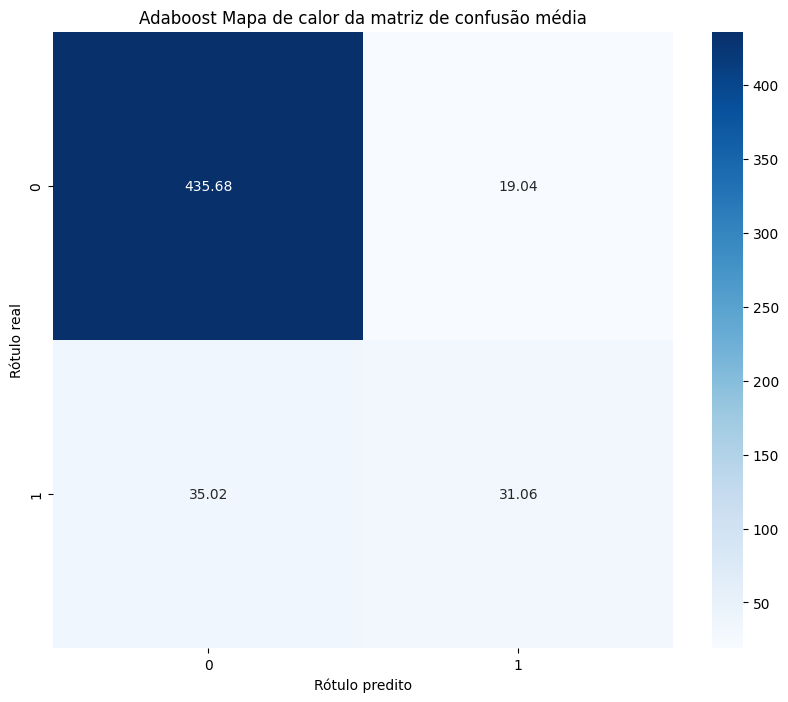

decision_tree - Precisão Média: 0.8865
decision_tree - Média de F1-Score: 0.8837
decision_tree - Mátriz de confusão média:
[[426.06  28.66]
 [ 30.66  35.42]]
decision_tree - F1-Score por classe 0: 0.9349
decision_tree - F1-Score por classe 1: 0.5443


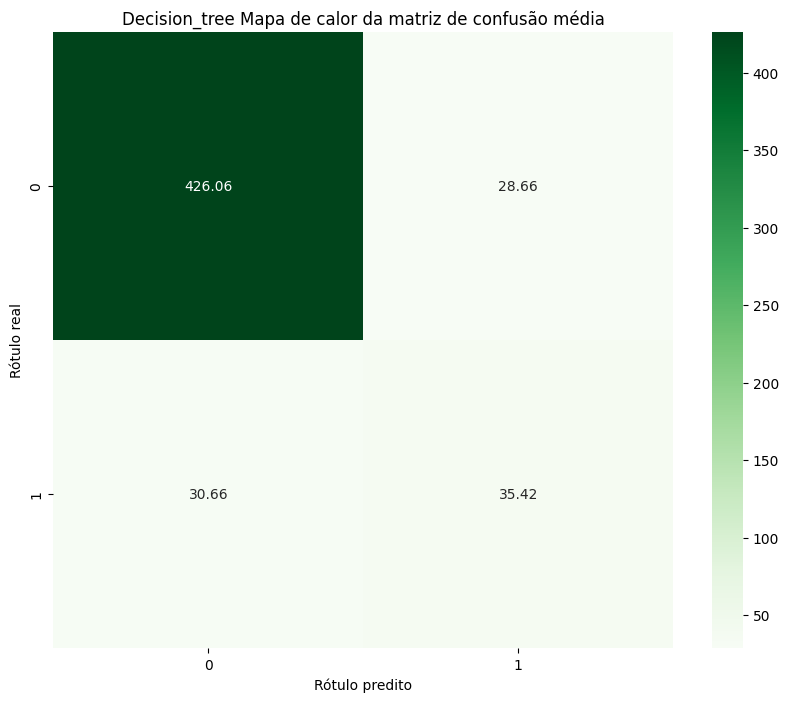

random_forest - Precisão Média: 0.9230
random_forest - Média de F1-Score: 0.9078
random_forest - Mátriz de confusão média:
[[447.84   6.88]
 [ 32.3   33.78]]
random_forest - F1-Score por classe 0: 0.9581
random_forest - F1-Score por classe 1: 0.6329


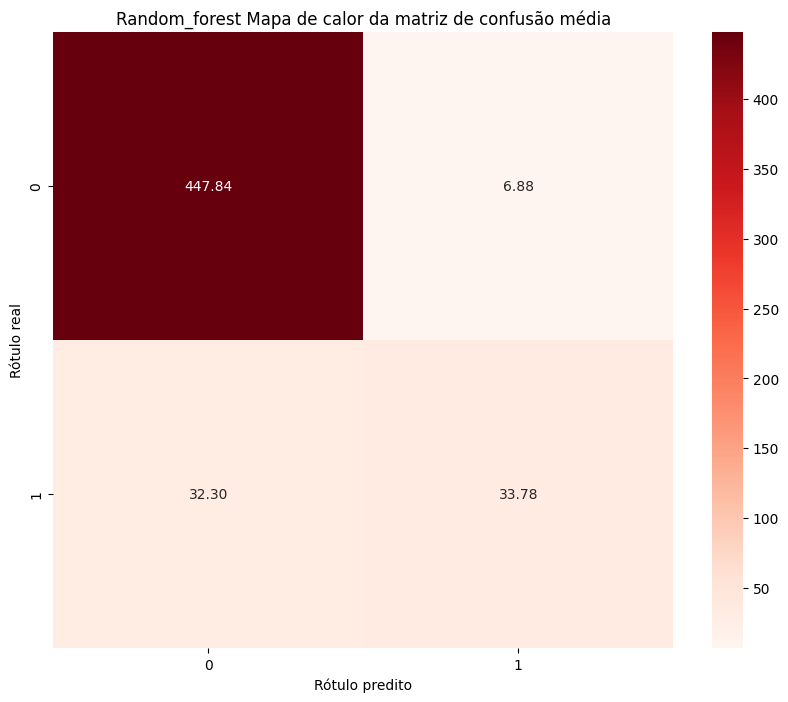

naive_bayes - Precisão Média: 0.6503
naive_bayes - Média de F1-Score: 0.7074
naive_bayes - Mátriz de confusão média:
[[273.72 181.  ]
 [  4.06  62.02]]
naive_bayes - F1-Score por classe 0: 0.7474
naive_bayes - F1-Score por classe 1: 0.4013


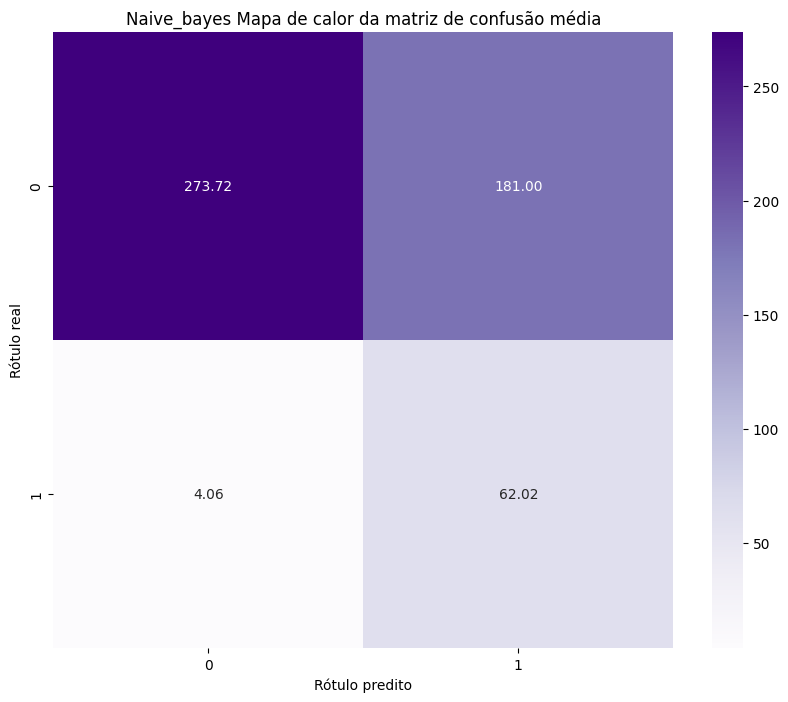

knn - Precisão Média: 0.8647
knn - Média de F1-Score: 0.8567
knn - Mátriz de confusão média:
[[426.5   28.22]
 [ 41.8   24.28]]
knn - F1-Score por classe 0: 0.9241
knn - F1-Score por classe 1: 0.4095


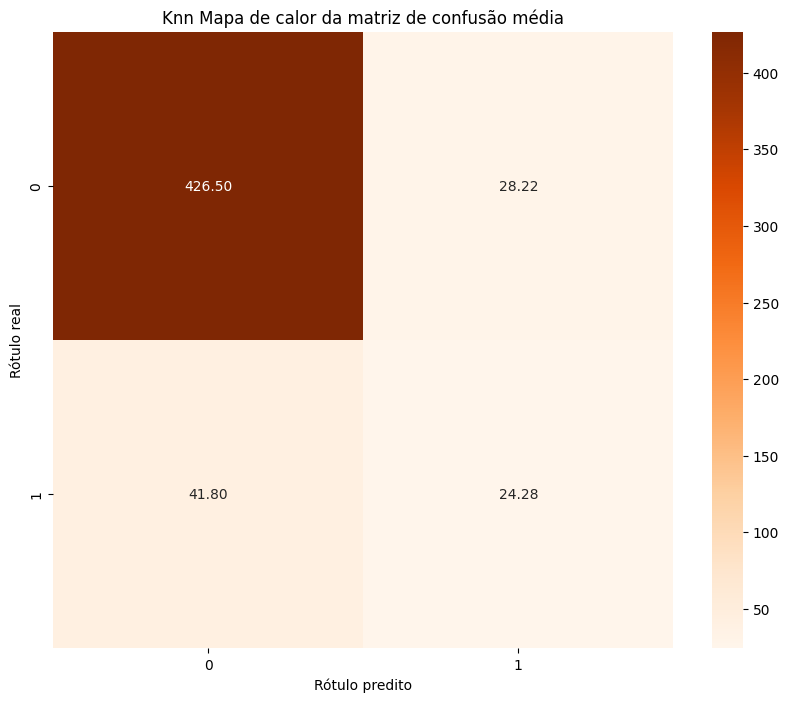

In [7]:
#PLOT BINARIO - PT
color_palettes = [
    "Blues", "Greens", "Reds", "Purples", "Oranges", "BuPu"
]

for idx, clf_name in enumerate(classifiers.keys()):
    mean_accuracy = np.mean(dict_info_names[clf_name]['accuracies'])
    mean_f1 = np.mean(dict_info_names[clf_name]['f1_scores'])
    mean_conf_matrix = np.mean(dict_info_names[clf_name]['confusion_matrices'], axis=0)
    
    print(f'{clf_name} - Precisão Média: {mean_accuracy:.4f}')
    print(f'{clf_name} - Média de F1-Score: {mean_f1:.4f}')
    print(f'{clf_name} - Mátriz de confusão média:')
    print(mean_conf_matrix)
    
    # Calculando F1-Score para cada classe individualmente
    num_classes = mean_conf_matrix.shape[0]
    f1_scores_per_class = []
    for i in range(num_classes):
        true_positives = mean_conf_matrix[i, i]
        false_positives = np.sum(mean_conf_matrix[:, i]) - true_positives
        false_negatives = np.sum(mean_conf_matrix[i, :]) - true_positives
        if true_positives + false_positives + false_negatives > 0:
            f1_class = 2 * true_positives / (2 * true_positives + false_positives + false_negatives)
        else:
            f1_class = 0.0
        f1_scores_per_class.append(f1_class)
        print(f'{clf_name} - F1-Score por classe {i}: {f1_class:.4f}')
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(mean_conf_matrix, annot=True, fmt=".2f", cmap=color_palettes[idx % len(color_palettes)])
    plt.title(f"{clf_name.capitalize()} Mapa de calor da matriz de confusão média")
    plt.xlabel("Rótulo predito")
    plt.ylabel("Rótulo real")
    plt.show()

    mean_conf_matrix_df = pd.DataFrame(mean_conf_matrix)
    mean_conf_matrix_df.to_csv(os.path.join(base_path, f'{clf_name}_mean_confusion_matrix.csv'), index=False, header=False)



adaboost - Mean Accuracy: 0.8937
adaboost - Mean F1-Score: 0.8837
adaboost - Mean Confusion Matrix:
[[435.68  19.04]
 [ 35.02  31.06]]
adaboost - F1-Score for class 0: 0.9416
adaboost - F1-Score for class 1: 0.5347


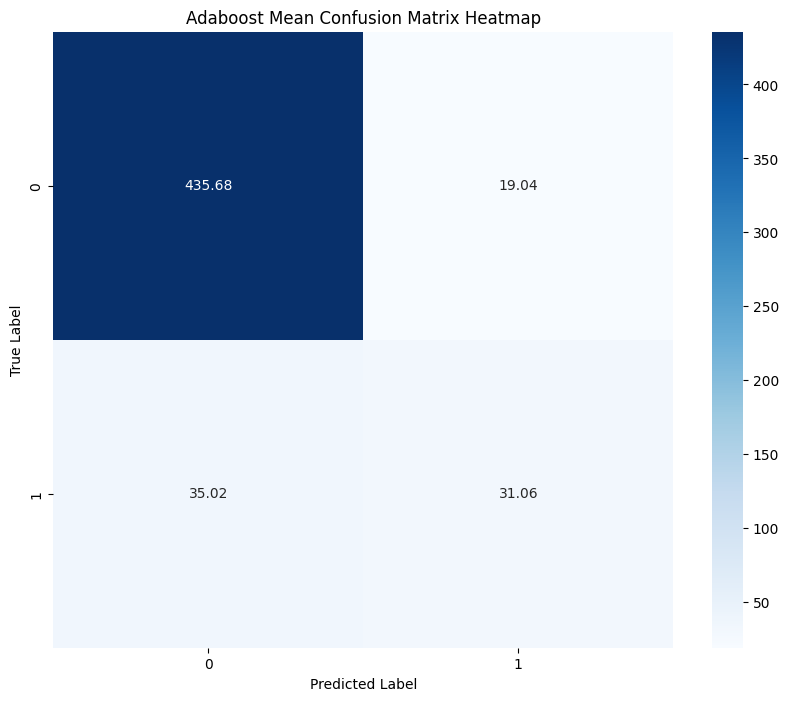

decision_tree - Mean Accuracy: 0.8865
decision_tree - Mean F1-Score: 0.8837
decision_tree - Mean Confusion Matrix:
[[426.06  28.66]
 [ 30.66  35.42]]
decision_tree - F1-Score for class 0: 0.9349
decision_tree - F1-Score for class 1: 0.5443


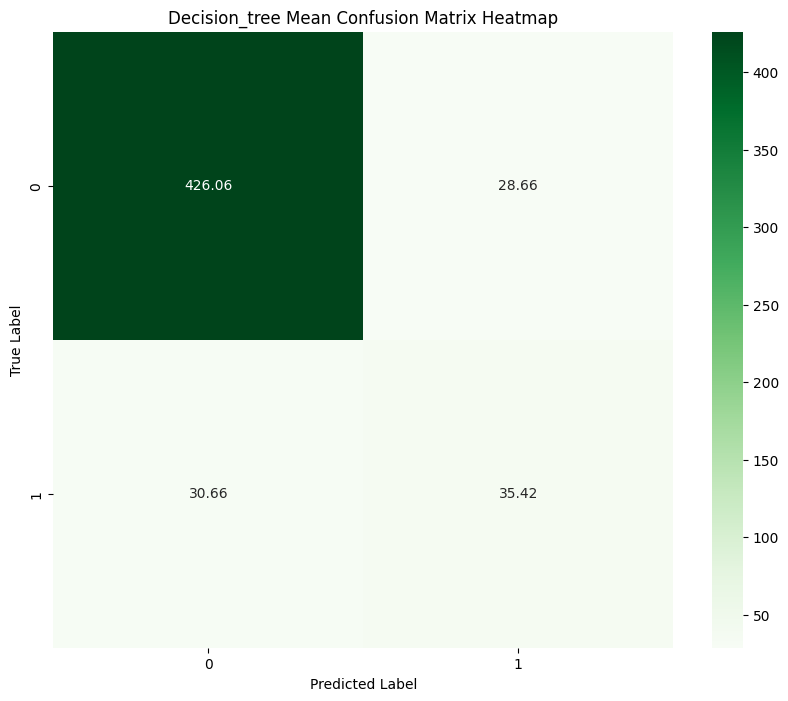

random_forest - Mean Accuracy: 0.9230
random_forest - Mean F1-Score: 0.9078
random_forest - Mean Confusion Matrix:
[[447.84   6.88]
 [ 32.3   33.78]]
random_forest - F1-Score for class 0: 0.9581
random_forest - F1-Score for class 1: 0.6329


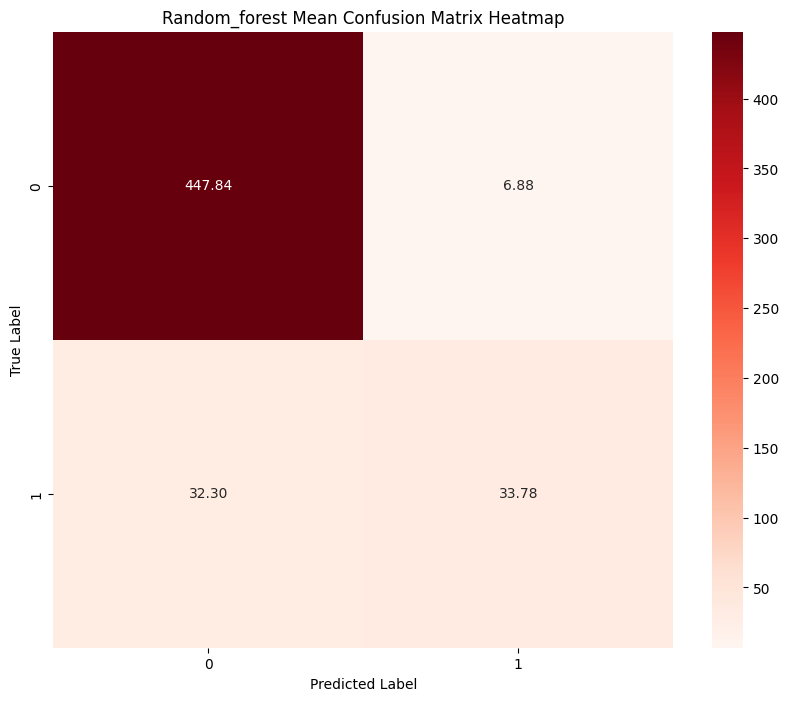

naive_bayes - Mean Accuracy: 0.6503
naive_bayes - Mean F1-Score: 0.7074
naive_bayes - Mean Confusion Matrix:
[[273.72 181.  ]
 [  4.06  62.02]]
naive_bayes - F1-Score for class 0: 0.7474
naive_bayes - F1-Score for class 1: 0.4013


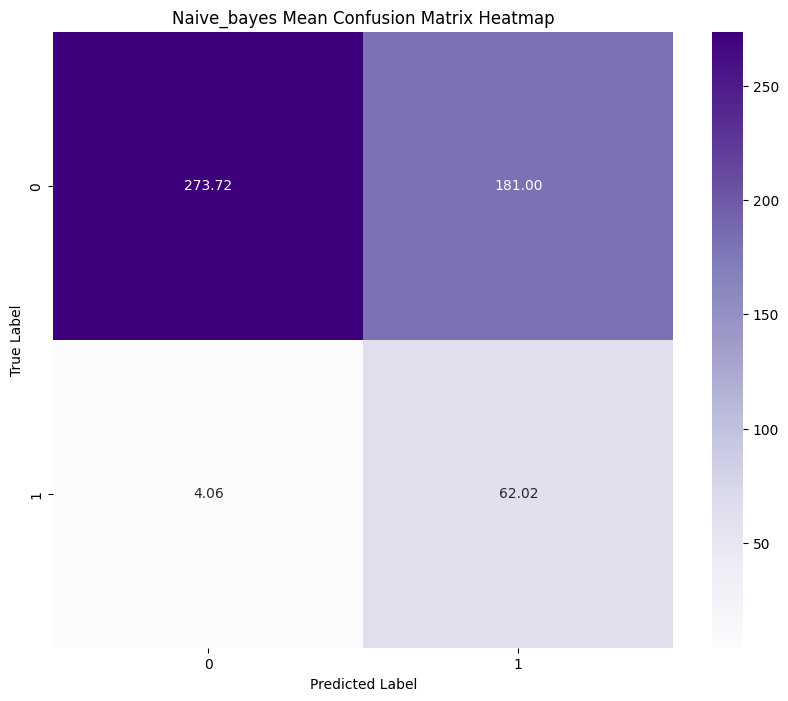

knn - Mean Accuracy: 0.8647
knn - Mean F1-Score: 0.8567
knn - Mean Confusion Matrix:
[[426.5   28.22]
 [ 41.8   24.28]]
knn - F1-Score for class 0: 0.9241
knn - F1-Score for class 1: 0.4095


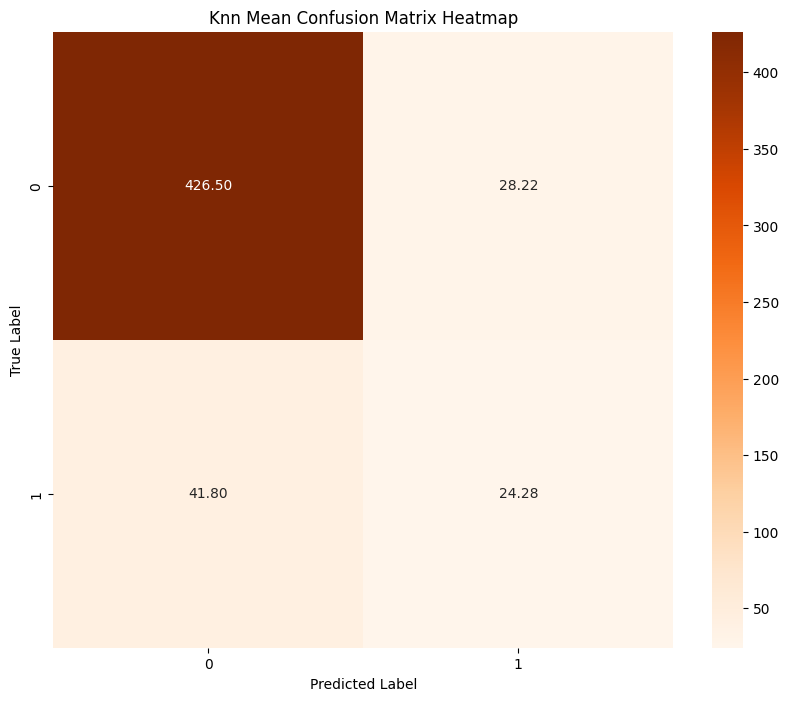

In [5]:
#PLOT BINARIO - EN
color_palettes = [
    "Blues", "Greens", "Reds", "Purples", "Oranges", "BuPu"
]

for idx, clf_name in enumerate(classifiers.keys()):
    mean_accuracy = np.mean(dict_info_names[clf_name]['accuracies'])
    mean_f1 = np.mean(dict_info_names[clf_name]['f1_scores'])
    mean_conf_matrix = np.mean(dict_info_names[clf_name]['confusion_matrices'], axis=0)
    
    print(f'{clf_name} - Mean Accuracy: {mean_accuracy:.4f}')
    print(f'{clf_name} - Mean F1-Score: {mean_f1:.4f}')
    print(f'{clf_name} - Mean Confusion Matrix:')
    print(mean_conf_matrix)
    
    # Calculando F1-Score para cada classe individualmente
    num_classes = mean_conf_matrix.shape[0]
    f1_scores_per_class = []
    for i in range(num_classes):
        true_positives = mean_conf_matrix[i, i]
        false_positives = np.sum(mean_conf_matrix[:, i]) - true_positives
        false_negatives = np.sum(mean_conf_matrix[i, :]) - true_positives
        if true_positives + false_positives + false_negatives > 0:
            f1_class = 2 * true_positives / (2 * true_positives + false_positives + false_negatives)
        else:
            f1_class = 0.0
        f1_scores_per_class.append(f1_class)
        print(f'{clf_name} - F1-Score for class {i}: {f1_class:.4f}')
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(mean_conf_matrix, annot=True, fmt=".2f", cmap=color_palettes[idx % len(color_palettes)])
    plt.title(f"{clf_name.capitalize()} Mean Confusion Matrix Heatmap")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    mean_conf_matrix_df = pd.DataFrame(mean_conf_matrix)
    mean_conf_matrix_df.to_csv(os.path.join(base_path, f'{clf_name}_mean_confusion_matrix.csv'), index=False, header=False)



In [6]:
import numpy as np

# Matriz de confusão SVM MULTICLASSE
conf_matrix = np.array([
    [2.453e+02, 5.240e+00, 2.800e+00, 1.400e-01, 2.000e-02, 8.000e-02, 2.000e-02, 4.200e-01],
    [1.680e+01, 2.760e+01, 2.660e+00, 8.000e-02, 0.000e+00, 0.000e+00, 2.000e-02, 4.000e-02],
    [9.820e+00, 5.100e+00, 8.080e+00, 2.600e-01, 1.400e-01, 1.800e-01, 1.200e-01, 2.800e-01],
    [8.400e-01, 9.200e-01, 3.800e-01, 8.800e-01, 0.000e+00, 0.000e+00, 4.000e-02, 4.400e-01],
    [1.180e+00, 1.160e+00, 1.180e+00, 6.000e-02, 8.000e-02, 1.400e-01, 8.000e-02, 0.000e+00],
    [1.940e+00, 6.200e-01, 9.800e-01, 2.000e-02, 6.000e-02, 5.400e-01, 1.600e-01, 0.000e+00],
    [1.340e+00, 1.020e+00, 7.800e-01, 1.000e-01, 8.000e-02, 4.600e-01, 2.000e-01, 2.000e-02],
    [1.400e+00, 4.200e-01, 2.200e-01, 1.600e-01, 0.000e+00, 0.000e+00, 0.000e+00, 2.300e+00]
])

# Função para calcular o F1-Score
def calculate_f1_score(conf_matrix, class_index):
    TP = conf_matrix[class_index, class_index]
    FP = np.sum(conf_matrix[:, class_index]) - TP
    FN = np.sum(conf_matrix[class_index, :]) - TP
    if TP + FP + FN > 0:
        precision = TP / (TP + FP)
        recall = TP / (TP + FN)
        f1_score = 2 * (precision * recall) / (precision + recall)
    else:
        f1_score = 0.0
    return f1_score

# Calculando os F1-Scores para as classes 0 e 1
f1_score_class_0 = calculate_f1_score(conf_matrix, 0)
f1_score_class_1 = calculate_f1_score(conf_matrix, 1)

print(f'F1-Score for class 0: {f1_score_class_0:.4f}')
print(f'F1-Score for class 1: {f1_score_class_1:.4f}')


F1-Score for class 0: 0.9211
F1-Score for class 1: 0.6183


adaboost - F1-Score for class 0: 0.9416
adaboost - F1-Score for class 1: 0.5347
decision_tree - F1-Score for class 0: 0.9349
decision_tree - F1-Score for class 1: 0.5443
random_forest - F1-Score for class 0: 0.9581
random_forest - F1-Score for class 1: 0.6329
naive_bayes - F1-Score for class 0: 0.7474
naive_bayes - F1-Score for class 1: 0.4013
knn - F1-Score for class 0: 0.9241
knn - F1-Score for class 1: 0.4095


<Figure size 1400x700 with 0 Axes>

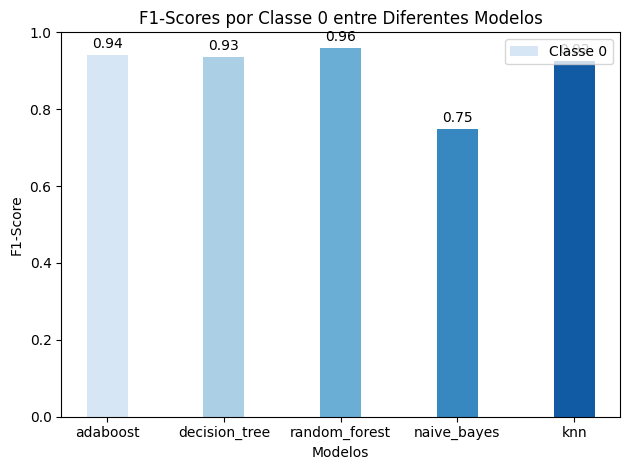

<Figure size 1400x700 with 0 Axes>

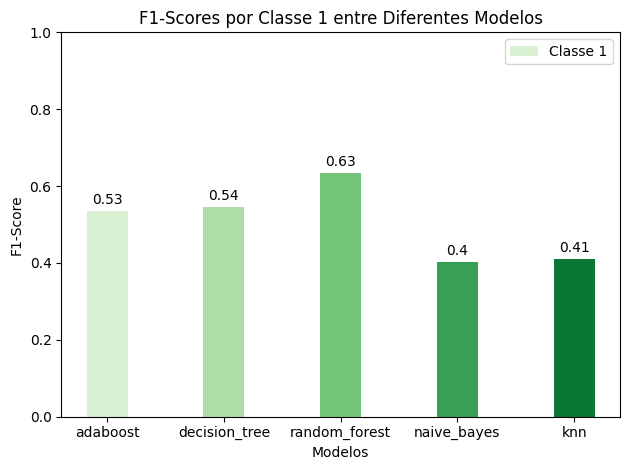

In [9]:
#Resultado F1-score em barras - BR
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Inicializando dicionários para armazenar os F1-Scores de todas as classes
f1_scores = {}

# Iterando pelos classificadores e calculando os F1-Scores para todas as classes
for clf_name in classifiers.keys():
    mean_conf_matrix = np.mean(dict_info_names[clf_name]['confusion_matrices'], axis=0)
    num_classes = mean_conf_matrix.shape[0]
    f1_scores[clf_name] = []
    
    for class_index in range(num_classes):
        true_positives = mean_conf_matrix[class_index, class_index]
        false_positives = np.sum(mean_conf_matrix[:, class_index]) - true_positives
        false_negatives = np.sum(mean_conf_matrix[class_index, :]) - true_positives
        if true_positives + false_positives + false_negatives > 0:
            f1_score = 2 * true_positives / (2 * true_positives + false_positives + false_negatives)
        else:
            f1_score = 0.0
        f1_scores[clf_name].append(f1_score)
        print(f'{clf_name} - F1-Score for class {class_index}: {f1_score:.4f}')

# Preparando os dados para o gráfico de barras
labels = list(f1_scores.keys())
num_classes = len(f1_scores[labels[0]])

# Lista de paletas de cores
color_palettes = [
    "Blues", "Greens", "Reds", "Purples", "Oranges", "BuPu"
]

# Criando gráficos de barras para cada classe
for class_index in range(num_classes):
    class_scores = [f1_scores[clf_name][class_index] for clf_name in labels]
    
    x = np.arange(len(labels))  # posição das labels no eixo x
    width = 0.35  # largura das barras

    plt.figure(figsize=(14, 7))
    fig, ax = plt.subplots()

    bars = ax.bar(x, class_scores, width, label=f'Classe {class_index}', color=sns.color_palette(color_palettes[class_index % len(color_palettes)], len(labels)))

    # Adicionando títulos e rótulos
    ax.set_xlabel('Modelos')
    ax.set_ylabel('F1-Score')
    ax.set_title(f'F1-Scores por Classe {class_index} entre Diferentes Modelos')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()

    # Adicionando rótulos nas barras
    def add_labels(bars):
        for bar in bars:
            height = bar.get_height()
            ax.annotate('{}'.format(round(height, 2)),
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom')

    add_labels(bars)

    plt.ylim(0, 1)  # Limite do eixo Y de 0 a 1
    fig.tight_layout()
    plt.show()



adaboost - F1-Score for class 1: 0.5347
decision_tree - F1-Score for class 1: 0.5443
random_forest - F1-Score for class 1: 0.6329
naive_bayes - F1-Score for class 1: 0.4013
knn - F1-Score for class 1: 0.4095


/tmp/ipykernel_875/1649049994.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(f1_scores_class_1.keys()), y=list(f1_scores_class_1.values()), palette="viridis")


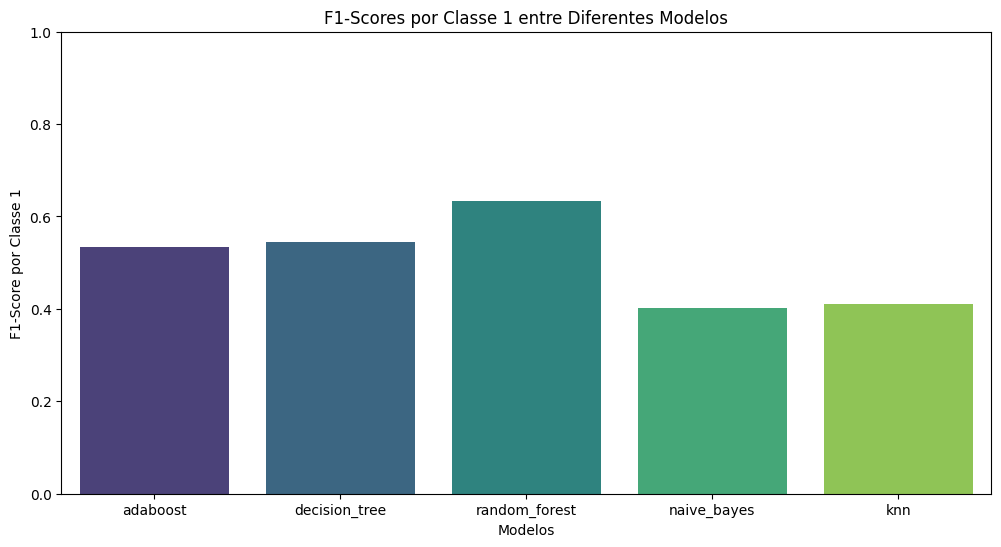

In [11]:
#Resultado F1-score em barras - BR
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Inicializando um dicionário para armazenar os F1-Scores da classe 1
f1_scores_class_1 = {}

# Iterando pelos classificadores e calculando os F1-Scores para a classe 1
for idx, clf_name in enumerate(classifiers.keys()):
    mean_conf_matrix = np.mean(dict_info_names[clf_name]['confusion_matrices'], axis=0)
    
    # Calculando F1-Score para a classe 1
    true_positives = mean_conf_matrix[1, 1]
    false_positives = np.sum(mean_conf_matrix[:, 1]) - true_positives
    false_negatives = np.sum(mean_conf_matrix[1, :]) - true_positives
    if true_positives + false_positives + false_negatives > 0:
        f1_class_1 = 2 * true_positives / (2 * true_positives + false_positives + false_negatives)
    else:
        f1_class_1 = 0.0

    f1_scores_class_1[clf_name] = f1_class_1
    print(f'{clf_name} - F1-Score for class 1: {f1_class_1:.4f}')

# Gerando o gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(x=list(f1_scores_class_1.keys()), y=list(f1_scores_class_1.values()), palette="viridis")
plt.title('F1-Scores por Classe 1 entre Diferentes Modelos')
plt.xlabel('Modelos')
plt.ylabel('F1-Score por Classe 1')
plt.ylim(0, 1)  # Limite do eixo Y de 0 a 1
plt.show()

adaboost - F1-Score for class 0: 0.9121
adaboost - F1-Score for class 1: 0.4920
adaboost - F1-Score for class 2: 0.3126
adaboost - F1-Score for class 3: 0.1735
adaboost - F1-Score for class 4: 0.1029
adaboost - F1-Score for class 5: 0.0859
adaboost - F1-Score for class 6: 0.0665
adaboost - F1-Score for class 7: 0.3930
decision_tree - F1-Score for class 0: 0.9131
decision_tree - F1-Score for class 1: 0.5543
decision_tree - F1-Score for class 2: 0.3269
decision_tree - F1-Score for class 3: 0.1384
decision_tree - F1-Score for class 4: 0.1000
decision_tree - F1-Score for class 5: 0.1415
decision_tree - F1-Score for class 6: 0.0923
decision_tree - F1-Score for class 7: 0.3448
random_forest - F1-Score for class 0: 0.9399
random_forest - F1-Score for class 1: 0.6893
random_forest - F1-Score for class 2: 0.4726
random_forest - F1-Score for class 3: 0.1911
random_forest - F1-Score for class 4: 0.0673
random_forest - F1-Score for class 5: 0.1622
random_forest - F1-Score for class 6: 0.0968
rando

<Figure size 1400x700 with 0 Axes>

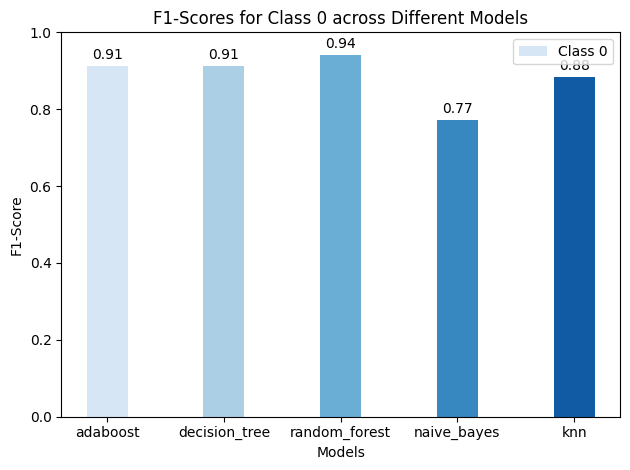

<Figure size 1400x700 with 0 Axes>

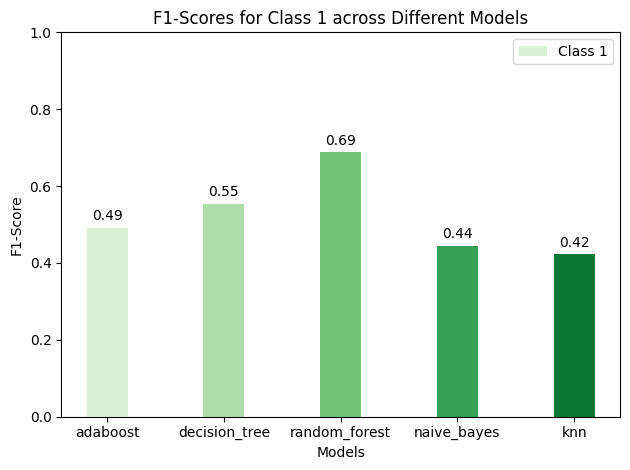

<Figure size 1400x700 with 0 Axes>

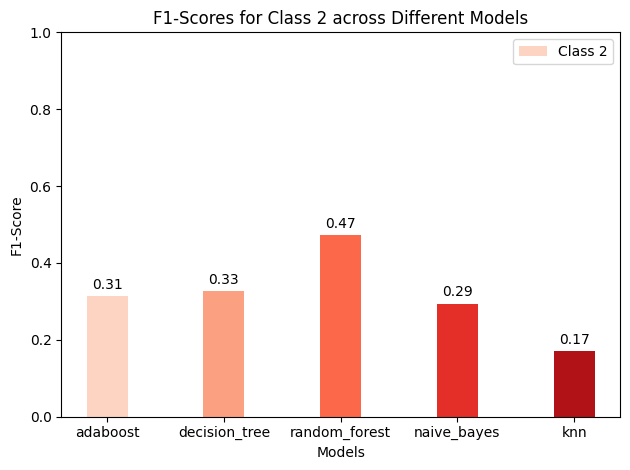

<Figure size 1400x700 with 0 Axes>

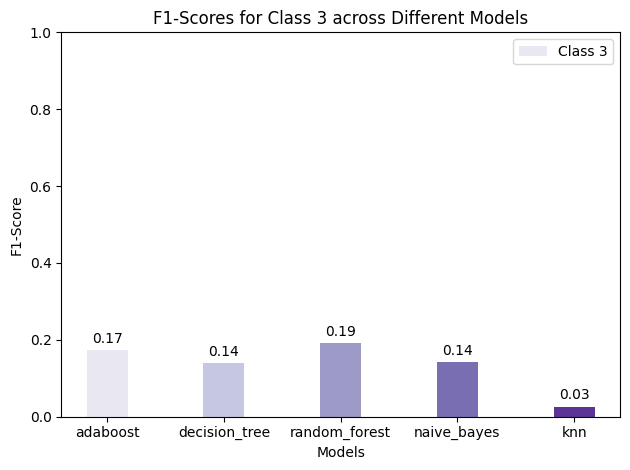

<Figure size 1400x700 with 0 Axes>

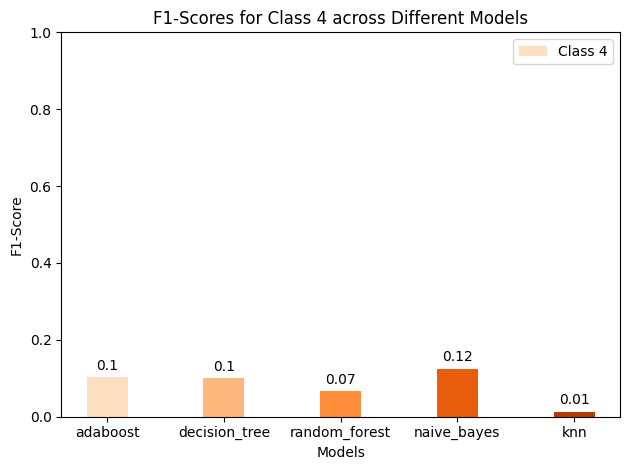

<Figure size 1400x700 with 0 Axes>

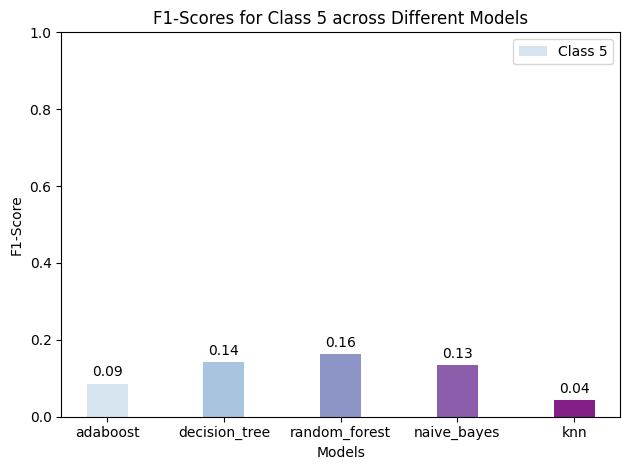

<Figure size 1400x700 with 0 Axes>

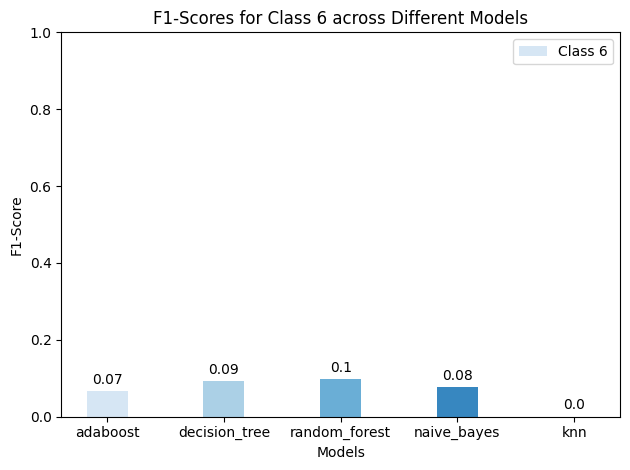

<Figure size 1400x700 with 0 Axes>

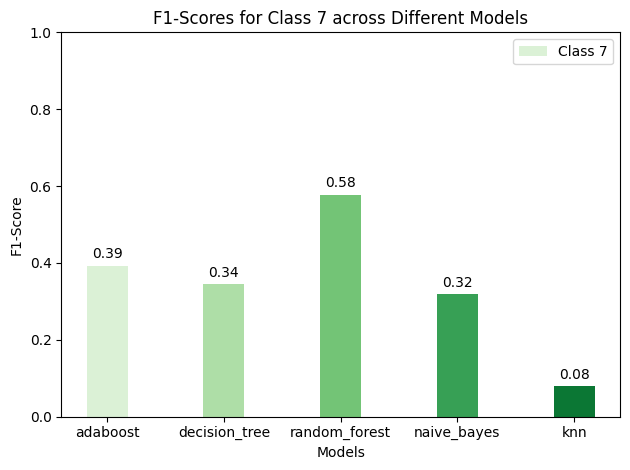

In [17]:
#Resultado F1-score em barras - EN
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Inicializando dicionários para armazenar os F1-Scores de todas as classes
f1_scores = {}

# Iterando pelos classificadores e calculando os F1-Scores para todas as classes
for clf_name in classifiers.keys():
    mean_conf_matrix = np.mean(dict_info_names[clf_name]['confusion_matrices'], axis=0)
    num_classes = mean_conf_matrix.shape[0]
    f1_scores[clf_name] = []
    
    for class_index in range(num_classes):
        true_positives = mean_conf_matrix[class_index, class_index]
        false_positives = np.sum(mean_conf_matrix[:, class_index]) - true_positives
        false_negatives = np.sum(mean_conf_matrix[class_index, :]) - true_positives
        if true_positives + false_positives + false_negatives > 0:
            f1_score = 2 * true_positives / (2 * true_positives + false_positives + false_negatives)
        else:
            f1_score = 0.0
        f1_scores[clf_name].append(f1_score)
        print(f'{clf_name} - F1-Score for class {class_index}: {f1_score:.4f}')

# Preparando os dados para o gráfico de barras
labels = list(f1_scores.keys())
num_classes = len(f1_scores[labels[0]])

# Lista de paletas de cores
color_palettes = [
    "Blues", "Greens", "Reds", "Purples", "Oranges", "BuPu"
]

# Criando gráficos de barras para cada classe
for class_index in range(num_classes):
    class_scores = [f1_scores[clf_name][class_index] for clf_name in labels]
    
    x = np.arange(len(labels))  # posição das labels no eixo x
    width = 0.35  # largura das barras

    plt.figure(figsize=(14, 7))
    fig, ax = plt.subplots()

    bars = ax.bar(x, class_scores, width, label=f'Class {class_index}', color=sns.color_palette(color_palettes[class_index % len(color_palettes)], len(labels)))

    # Adicionando títulos e rótulos
    ax.set_xlabel('Models')
    ax.set_ylabel('F1-Score')
    ax.set_title(f'F1-Scores for Class {class_index} across Different Models')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()

    # Adicionando rótulos nas barras
    def add_labels(bars):
        for bar in bars:
            height = bar.get_height()
            ax.annotate('{}'.format(round(height, 2)),
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom')

    add_labels(bars)

    plt.ylim(0, 1)  # Limite do eixo Y de 0 a 1
    fig.tight_layout()
    plt.show()



adaboost - F1-Score for class 1: 0.5347
decision_tree - F1-Score for class 1: 0.5443
random_forest - F1-Score for class 1: 0.6329
naive_bayes - F1-Score for class 1: 0.4013
knn - F1-Score for class 1: 0.4095


/tmp/ipykernel_648/2735332107.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(f1_scores_class_1.keys()), y=list(f1_scores_class_1.values()), palette="viridis")


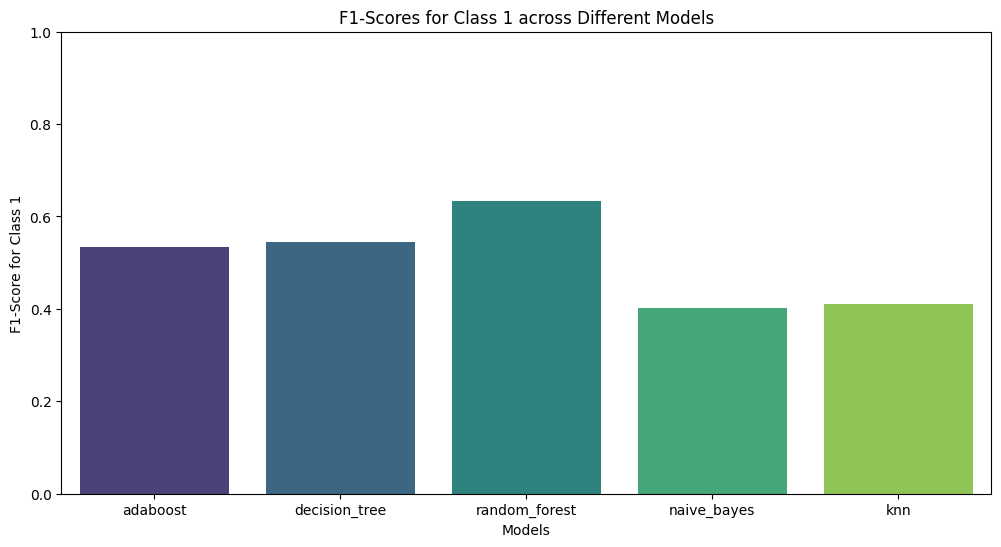

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Inicializando um dicionário para armazenar os F1-Scores da classe 1
f1_scores_class_1 = {}

# Iterando pelos classificadores e calculando os F1-Scores para a classe 1
for idx, clf_name in enumerate(classifiers.keys()):
    mean_conf_matrix = np.mean(dict_info_names[clf_name]['confusion_matrices'], axis=0)
    
    # Calculando F1-Score para a classe 1
    true_positives = mean_conf_matrix[1, 1]
    false_positives = np.sum(mean_conf_matrix[:, 1]) - true_positives
    false_negatives = np.sum(mean_conf_matrix[1, :]) - true_positives
    if true_positives + false_positives + false_negatives > 0:
        f1_class_1 = 2 * true_positives / (2 * true_positives + false_positives + false_negatives)
    else:
        f1_class_1 = 0.0

    f1_scores_class_1[clf_name] = f1_class_1
    print(f'{clf_name} - F1-Score for class 1: {f1_class_1:.4f}')

# Gerando o gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(x=list(f1_scores_class_1.keys()), y=list(f1_scores_class_1.values()), palette="viridis")
plt.title('F1-Scores for Class 1 across Different Models')
plt.xlabel('Models')
plt.ylabel('F1-Score for Class 1')
plt.ylim(0, 1)  # Limite do eixo Y de 0 a 1
plt.show()

In [25]:
# Exibindo resultados finais e média das matrizes de confusão
final_acc = [info['accuracy'] for info in dict_info_names.values()]
final_f1 = [info['f1-score'] for info in dict_info_names.values()]

print('Mean Accuracy:', np.mean(final_acc))
print('Mean F1-score:', np.mean(final_f1))
mean_conf_matrix = np.mean(confusion_matrices, axis=0)
print("Mean Confusion Matrix:")
print(mean_conf_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(mean_conf_matrix, annot=True, fmt=".2f", cmap="Blues")
plt.title("Mean Confusion Matrix Heatmap")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

mean_conf_matrix_df = pd.DataFrame(mean_conf_matrix)
mean_conf_matrix_df.to_csv(os.path.join(base_path, 'mean_confusion_matrix.csv'), index=False, header=False)

KeyError: 'accuracy'

In [11]:

DATASET_PATH = "/home/danielgohl/datasets/quick_test/"
filenames = glob.glob(os.path.join(DATASET_PATH, "idp*.csv"))
base_path = os.path.join(DATASET_PATH, "test-huang-regression-multiclasse-1")

window_size = 3 * 200
overlap_size = int(0.50 * window_size)
columns = ['accX', 'accY', 'accZ', 'asX', 'asY', 'asZ']
columns_to_use = columns + ['label']

leave_out, dict_info_names, confusion_matrices = load_progress(base_path)

while leave_out < len(filenames):
    filename = filenames[leave_out]
    print(f'Processing file {leave_out + 1}/{len(filenames)}: {filename}')
    selected_files = filenames.copy()
    selected_files.pop(leave_out)
    dfs = [pd.read_csv(file, usecols=columns_to_use) for file in selected_files]
    df_train = pd.concat(dfs, axis=0, ignore_index=True)
    df_train['label'] = df_train['label'].apply(lambda x: 0 if x != 1 else 1)
    print(df_train['label'].unique())
    df_test = pd.read_csv(filename, usecols=columns_to_use)
    df_test['label'] = df_test['label'].apply(lambda x: 0 if x != 1 else 1)

    X_train, X_test, y_train, y_test = main_train(df_train, df_test, window_size, overlap_size, columns)
    print("Final datasets with size: | train {0} | test {1} | ".format(X_train.shape, X_test.shape))
    accuracy, f1, report, conf_matrix = run_regression(X_train, X_test, y_train, y_test)
    #print(report)
    dict_info_names[filename.split('/')[-1]] = {'accuracy': accuracy, 'f1-score': f1}
    confusion_matrices.append(conf_matrix)
    leave_out += 1
    save_progress(leave_out, dict_info_names, confusion_matrices, base_path)

final_acc = [info['accuracy'] for info in dict_info_names.values()]
final_f1 = [info['f1-score'] for info in dict_info_names.values()]

#print('Mean Accuracy:', np.mean(final_acc))
#print('Mean F1-score:', np.mean(final_f1))
mean_conf_matrix = np.mean(confusion_matrices, axis=0)
#print("Mean Confusion Matrix:")
#print(mean_conf_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(mean_conf_matrix, annot=True, fmt=".2f", cmap="Purples")
plt.title("Média Matriz de Confusão")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")
plt.show()

mean_conf_matrix_df = pd.DataFrame(mean_conf_matrix)
mean_conf_matrix_df.to_csv(os.path.join(base_path, 'mean_confusion_matrix.csv'), index=False, header=False)
mean_conf_matrix_df.to_csv(os.path.join(base_path, 'mean_confusion_matrix.csv'), index=False, header=False)

Progress file not found.
Processing file 1/6: /home/danielgohl/datasets/quick_test/idp014_idc016_R_bottle_p10minV.2.1.csv
[0 1]
Final datasets with size: | train (1341, 48) | test (268, 48) | 


/tmp/ipykernel_768/2452653034.py:115: RuntimeWarning: divide by zero encountered in divide
  mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100


ValueError: not enough values to unpack (expected 4, got 2)